In [1]:
import pandas as pd

# Read the Excel file
df = pd.read_excel('Experiment Tracker.xlsx', sheet_name=['T30 categorization', 'T60 categorization'])

# Categorization at time=30
group_10 = set(df['T30 categorization']['Group_10'].dropna())
group_20 = set(df['T30 categorization']['Group_20'].dropna())
group_30 = set(df['T30 categorization']['Group_30'].dropna())

# Categorization at time=60
full_occlusion = set(df['T60 categorization']['Full_Occlusion'].dropna())
partial_occlusion = set(df['T60 categorization']['Partial_Occlusion'].dropna())
no_occlusion = set(df['T60 categorization']['No_Occlusion'].dropna())

# Print or use the variables as needed
print("Categorization at time=30:")
print("Group 10:", group_10)
print("Group 20:", group_20)
print("Group 30:", group_30)

print("\nCategorization at time=60:")
print("Full Occlusion:", full_occlusion)
print("Partial Occlusion:", partial_occlusion)
print("No Occlusion:", no_occlusion)

# Find overlapping subjects for each combination at time=0
# Combine the sets
t_0_data = group_10 | group_20 | group_30

# Convert the set to a sorted list
sorted_t_0_data = sorted(t_0_data)


# Print the combined set
print("\nAvailable data at time=0:", sorted_t_0_data)


print("\n10% Hemorrhage: ", group_10)
print("\n20% Hemorrhage: ", group_20)
print("\n30% Hemorrhage: ", group_30)

# Find overlapping subjects for each combination at time=60
hemorrhage_10_full_occlusion = group_10.intersection(full_occlusion)
hemorrhage_10_partial_occlusion = group_10.intersection(partial_occlusion)
hemorrhage_10_no_occlusion = group_10.intersection(no_occlusion)

hemorrhage_20_full_occlusion = group_20.intersection(full_occlusion)
hemorrhage_20_partial_occlusion = group_20.intersection(partial_occlusion)
hemorrhage_20_no_occlusion = group_20.intersection(no_occlusion)

hemorrhage_30_full_occlusion = group_30.intersection(full_occlusion)
hemorrhage_30_partial_occlusion = group_30.intersection(partial_occlusion)
hemorrhage_30_no_occlusion = group_30.intersection(no_occlusion)

Categorization at time=30:
Group 10: {'ERNE44', 'ERNE33', 'ERNE23', 'ERNE27', 'ERNE32', 'ERNE25', 'ERNE58', 'ERNE61', 'ERNE39', 'ERNE59', 'ERNE70', 'ERNE12', 'ERNE48', 'ERNE38', 'ERNE67', 'ERNE62', 'ERNE40', 'ERNE10'}
Group 20: {'ERNE21', 'ERNE30', 'ERNE56', 'ERNE47', 'ERNE34', 'ERNE19', 'ERNE60', 'ERNE63', 'ERNE51', 'ERNE53', 'ERNE45', 'ERNE71', 'ERNE50', 'ERNE54', 'ERNE69', 'ERNE49', 'ERNE72', 'ERNE41'}
Group 30: {'ERNE5', 'ERNE64', 'ERNE57', 'ERNE20', 'ERNE14', 'ERNE52', 'ERNE26', 'ERNE29', 'ERNE31', 'ERNE55', 'ERNE66', 'ERNE35', 'ERNE68', 'ERNE43', 'ERNE2', 'ERNE65', 'ERNE36', 'ERNE7'}

Categorization at time=60:
Full Occlusion: {'ERNE44', 'ERNE56', 'ERNE57', 'ERNE14', 'ERNE10', 'ERNE65', 'ERNE26', 'ERNE70', 'ERNE19', 'ERNE12', 'ERNE63', 'ERNE38', 'ERNE45', 'ERNE2', 'ERNE69', 'ERNE59', 'ERNE7', 'ERNE41'}
Partial Occlusion: {'ERNE64', 'ERNE21', 'ERNE27', 'ERNE32', 'ERNE47', 'ERNE25', 'ERNE55', 'ERNE58', 'ERNE39', 'ERNE35', 'ERNE51', 'ERNE68', 'ERNE62', 'ERNE71', 'ERNE49', 'ERNE43', 

In [2]:
import os
import pandas as pd

# Define the paths and arrays
parent_folder_path = os.getcwd()  # Change this to the actual path
parent_folders = os.listdir(parent_folder_path)

# Function to process raw data

def process_raw_data(parent_folders, group_10, group_20, group_30,
                     hemorrhage_10_full_occlusion, hemorrhage_10_partial_occlusion, hemorrhage_10_no_occlusion,
                     hemorrhage_20_full_occlusion, hemorrhage_20_partial_occlusion, hemorrhage_20_no_occlusion,
                     hemorrhage_30_full_occlusion, hemorrhage_30_partial_occlusion, hemorrhage_30_no_occlusion):
    raw_data_list = []
    hemorrhage_levels = {10: "10%", 20: "20%", 30: "30%"}
    treatment_groups = {
        'full_occlusion': 'Full',
        'partial_occlusion': 'Partial',
        'no_occlusion': 'None'
    }
    
    second_layer_folders = [
        'T0-1',
#         'T5-6', 'T10-11', 'T15-16', 'T20-21', 
        # 'T25-26',
        'T29-30',
#         'T30-T31', 
        # 'T35-36', 'T40-41', 'T45-46',
        # 'T50-51', 'T55-56', 'T59-60',
        # 'T60-61',
        
        # 'T64-65', 
        # 'T65-66', 
        # 'T70-71', 
        # 'T74-75',
        # 'T75-76',
        # 'T80-81',
        # 'T84-85', 'T85-86', 'T90-91', 'T120-121', 'T180-181', 
        'T239-240'
    ]
    
    for parent_folder in parent_folders:
        parent_folder_full_path = os.path.join(parent_folder_path, parent_folder)
        if os.path.isdir(parent_folder_full_path):
            for second_layer_folder in second_layer_folders:
                second_layer_full_path = os.path.join(parent_folder_full_path, second_layer_folder)
                if os.path.isdir(second_layer_full_path):
                    file_name = f"{parent_folder}_T{second_layer_folder}_PV_Output.xlsx"
                    file_path = os.path.join(second_layer_full_path, file_name)

                    if os.path.isfile(file_path):
                        df = pd.read_excel(file_path, sheet_name='Ensemble PV Loop')
                        df["Row Index"] = df.index + 1  # Track row number
                        df["Parent Folder"] = parent_folder
                        df["Time Point"] = second_layer_folder
                        
                        # Determine Hemorrhage Level
                        hemorrhage_level = None
                        for level in [10, 20, 30]:
                            if parent_folder in globals()[f'group_{level}']:
                                hemorrhage_level = level
                                break
                        if hemorrhage_level is not None:
                            df["Hemorrhage Level"] = hemorrhage_level
                        else:
                            print(parent_folder, "Not found in any bleed group")
                            continue

                        # Determine Treatment Group
                        treatment = None
                        for level in [10, 20, 30]:
                            for occlusion in ['full_occlusion', 'partial_occlusion', 'no_occlusion']:
                                if parent_folder in globals()[f'hemorrhage_{level}_{occlusion}']:
                                    treatment = f'{hemorrhage_levels[level]} {treatment_groups[occlusion]}'
                                    break
                            if treatment:
                                break
                        if treatment is not None:
                            df["Treatment Group"] = treatment
                        else:
                            print(parent_folder, "Not found in any treatment group")
                            continue

                        raw_data_list.append(df)

    if raw_data_list:
        raw_data_array = pd.concat(raw_data_list, ignore_index=True)
    else:
        raw_data_array = pd.DataFrame()

    return raw_data_array

# Process and merge data
PV_raw_data = process_raw_data(parent_folders, group_10, group_20, group_30,
                               hemorrhage_10_full_occlusion, hemorrhage_10_partial_occlusion, hemorrhage_10_no_occlusion,
                               hemorrhage_20_full_occlusion, hemorrhage_20_partial_occlusion, hemorrhage_20_no_occlusion,
                               hemorrhage_30_full_occlusion, hemorrhage_30_partial_occlusion, hemorrhage_30_no_occlusion)

# Load "Weights and Genders.xlsx" to append relevant data
weights_genders_df = pd.read_excel("Weights and Genders.xlsx")

# Merge weight and gender information
PV_raw_data = PV_raw_data.merge(weights_genders_df, on="Parent Folder", how="left")

# Save final dataset
PV_raw_data.to_excel('PV_Ensemble_Data-Raw.xlsx', index=False)

# Print parent folders
print(parent_folders)
!pwd


['~$QA Log.xlsx', 'abandonedEnsemble Waveform Gather.ipynb', 'ERNE65.xlsx', 'ERNE32.xlsx', 'ERNE49.xlsx', '~$ERNE49.xlsx', 'Standard Working Waveform Analysis.ipynb', 'ERNE69.xlsx', 'Ensemble Averaged PV Plots.ipynb', 'ERNE45.xlsx', 'ERNE12.xlsx', 'QA Log.xlsx', 'ERNE53.xlsx', 'ERNE52.xlsx', 'ERNE7.xlsx', 'ERNE55', 'ERNE52', 'Low Pass Filter Sandbox.ipynb', 'ERNE64', '~$ERNE72.xlsx', 'CNN Input Data Generator with BL.ipynb', 'Main Function.ipynb', '.DS_Store', 'ERNE44.xlsx', 'ERNE63', 'ERNE30', '~$Ensemble Averaged Raw Loops.xlsx', 'ERNE68.xlsx', 'ERNE39', '~$ERNE48.xlsx', 'ERNE29.xlsx', 'All Occlusion Groups Plots.ipynb', 'ERNE62', 'Waveform Total Output.xlsx', 'ERNE65', 'ERNE53', 'ERNE48.xlsx', 'ERNE54', 'ERNE33.xlsx', 'ERNE64.xlsx', 'ERNE38', 'ERNE31', 'ERNE72.xlsx', 'ERNE36', 'ERNE25.xlsx', 'ERNE14', 'ERNE2', 'ERNE25', 'ERNE5', 'ERNE38.xlsx', 'PV Loop Data.ipynb', 'ERNE43.xlsx', 'ERNE49', 'ERNE14.xlsx', 'ERNE71', '~$Weights and Genders.xlsx', 'ERNE47', 'ERNE55.xlsx', 'ERNE40', 'TXT

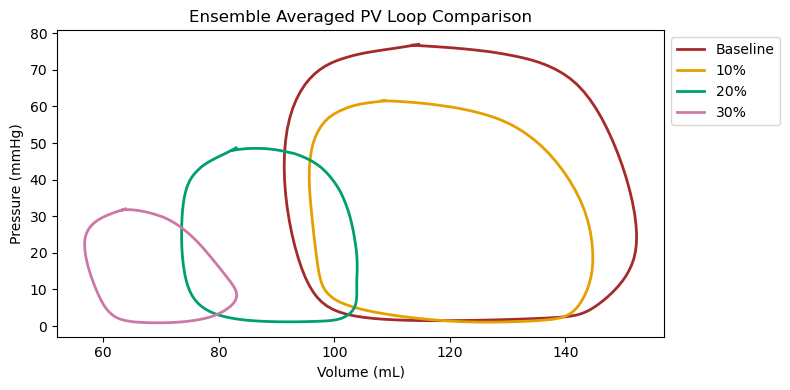

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# # Load Excel data
# df = pd.read_excel('PV_Ensemble_Data-Raw.xlsx')

# # Define new groups
# groups = {
#     "group_10": group_10,
#     "group_20": group_20,
#     "group_30": group_30,
# }

# # Create a combined group containing all folders
# combined_group = set(group_10) | set(group_20) | set(group_30)

# # Filter to keep only the relevant time points
# df = df[df['Time Point'].isin(["T0-1", "T29-30"])]

# # Treat all "T0-1" as "T0"
# df.loc[df['Time Point'] == "T0-1", 'Time Point'] = "T0"

# group_rename = {
#     "group_10": "10%",
#     "group_20": "20%",
#     "group_30": "30%",
#     "combined": "Baseline"
# }


# # Function to normalize array length
# def resize_array(data, target_length):
#     if len(data) == 0:
#         return np.zeros((target_length, data.shape[1]))  # Return zeros if empty
#     x_original = np.linspace(0, 1, len(data))
#     x_target = np.linspace(0, 1, target_length)
#     interpolator = interp1d(x_original, data, axis=0, kind='linear', fill_value='extrapolate')
#     return interpolator(x_target)

# # Process each group
# universal_pressure = {}
# universal_volume = {}

# time_points = df['Time Point'].unique()

# for time_point in time_points:
#     df_time = df[df['Time Point'] == time_point]
    
#     # Special handling: Only add "combined" for T0
#     if time_point == "T0":
#         groups_to_process = {"combined": combined_group}
#     else:
#         groups_to_process = {k: v for k, v in groups.items()}  # Regular groups for T25-26

#     for group_name, parent_folders in groups_to_process.items():
#         group_data = []
#         for folder in parent_folders:
#             subset = df_time[df_time['Parent Folder'] == folder].sort_values('Row Index')
#             if not subset.empty:
#                 group_data.append(subset[['Pressure', 'Volume']].to_numpy())
        
#         if not group_data:
#             print(f"Skipping {group_name} at Time Point {time_point} (no data)")
#             continue  # Skip empty groups
        
#         # Determine average length
#         avg_length = int(np.mean([len(data) for data in group_data]))
        
#         # Resize each dataset
#         resized_data = [resize_array(data, avg_length) for data in group_data]
        
#         # Compute mean across resized datasets
#         mean_pressure = np.mean([data[:, 0] for data in resized_data], axis=0)
#         mean_volume = np.mean([data[:, 1] for data in resized_data], axis=0)
        
#         key = f"{group_name}_T{time_point}"
#         universal_pressure[key] = mean_pressure
#         universal_volume[key] = mean_volume

# # Prepare data for export to Excel
# export_data = {}
# for key in universal_pressure.keys():
#     group_name, time_point = key.split('_T')  # Extract group name and time point
#     display_name = group_rename.get(group_name, group_name)
    
#     # Create DataFrame for each group and time point
#     export_data[display_name] = pd.DataFrame({
#         'Volume': universal_volume[key],
#         'Pressure': universal_pressure[key]
#     })

# # Save to Excel
# with pd.ExcelWriter('Ensemble Averaged Raw Loops.xlsx') as writer:
#     for group, data in export_data.items():
#         data.to_excel(writer, sheet_name=group, index=False)

# # Plot results using Matplotlib (same as before)
# plt.figure(figsize=(10, 4))

# for key in universal_pressure.keys():
#     group_name, time_point = key.split('_T')  # Extract group name and time point
#     display_name = f"{group_rename.get(group_name, group_name)}"
#     plt.plot(universal_volume[key], universal_pressure[key], label=display_name)

# plt.xlabel("Volume (mL)")
# plt.ylabel("Pressure (mmHg)")
# plt.title("Ensemble Averaged PV Loop Comparison")
# plt.grid(True, which='major')  # Keep only major gridlines
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot
# plt.tight_layout(rect=[0, 0, 0.8, 1])  # Adjust layout to fit legend outside
# plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# -------------------------------
# Load Excel data
# -------------------------------
df = pd.read_excel('PV_Ensemble_Data-Raw.xlsx')

# Define new groups
groups = {
    "group_10": group_10,
    "group_20": group_20,
    "group_30": group_30,
}

# Create a combined group containing all folders
combined_group = set(group_10) | set(group_20) | set(group_30)

# Filter to keep only the relevant time points
df = df[df['Time Point'].isin(["T0-1", "T29-30"])]

# Treat all "T0-1" as "T0"
df.loc[df['Time Point'] == "T0-1", 'Time Point'] = "T0"

# Rename groups for display
group_rename = {
    "group_10": "10%",
    "group_20": "20%",
    "group_30": "30%",
    "combined": "Baseline"
}

# -------------------------------
# Function to normalize array length
# -------------------------------
def resize_array(data, target_length):
    if len(data) == 0:
        return np.zeros((target_length, data.shape[1]))  # Return zeros if empty
    x_original = np.linspace(0, 1, len(data))
    x_target = np.linspace(0, 1, target_length)
    interpolator = interp1d(x_original, data, axis=0, kind='linear', fill_value='extrapolate')
    return interpolator(x_target)

# -------------------------------
# Process each group
# -------------------------------
universal_pressure = {}
universal_volume = {}

time_points = df['Time Point'].unique()

for time_point in time_points:
    df_time = df[df['Time Point'] == time_point]
    
    # Special handling: Only add "combined" for T0
    if time_point == "T0":
        groups_to_process = {"combined": combined_group}
    else:
        groups_to_process = {k: v for k, v in groups.items()}  # Regular groups for T29-30

    for group_name, parent_folders in groups_to_process.items():
        group_data = []
        for folder in parent_folders:
            subset = df_time[df_time['Parent Folder'] == folder].sort_values('Row Index')
            if not subset.empty:
                group_data.append(subset[['Pressure', 'Volume']].to_numpy())
        
        if not group_data:
            print(f"Skipping {group_name} at Time Point {time_point} (no data)")
            continue  # Skip empty groups
        
        # Determine average length
        avg_length = int(np.mean([len(data) for data in group_data]))
        
        # Resize each dataset
        resized_data = [resize_array(data, avg_length) for data in group_data]
        
        # Compute mean across resized datasets
        mean_pressure = np.mean([data[:, 0] for data in resized_data], axis=0)
        mean_volume = np.mean([data[:, 1] for data in resized_data], axis=0)
        
        key = f"{group_name}_T{time_point}"
        universal_pressure[key] = mean_pressure
        universal_volume[key] = mean_volume

# -------------------------------
# Prepare data for export to Excel
# -------------------------------
export_data = {}
for key in universal_pressure.keys():
    group_name, time_point = key.split('_T')  # Extract group name and time point
    display_name = group_rename.get(group_name, group_name)
    
    # Create DataFrame for each group and time point
    export_data[display_name] = pd.DataFrame({
        'Volume': universal_volume[key],
        'Pressure': universal_pressure[key]
    })

# Save to Excel
with pd.ExcelWriter('Ensemble Averaged Raw Loops.xlsx') as writer:
    for group, data in export_data.items():
        data.to_excel(writer, sheet_name=group, index=False)

# -------------------------------
# Plot results with Savitzky-Golay smoothing
# -------------------------------

# Define colors for each line (avoid blue, red, black)
line_colors = {
    "10%": "#E69F00",
    "20%": "#009E73",
    "30%": "#CC79A7",
    "Baseline": "brown"
}

# color_palette = ['#E69F00', '#009E73', '#CC79A7']  # Orange, Teal, Purple

# Parameters for Savitzky-Golay filter
window_length = 19  # must be odd and <= length of your data
polyorder = 3      # polynomial order

plt.figure(figsize=(10, 4))

for key in universal_pressure.keys():
    group_name, time_point = key.split('_T')
    display_name = group_rename.get(group_name, group_name)
    color = line_colors.get(display_name, "gray")

    # Apply Savitzky-Golay filter
    smooth_pressure = savgol_filter(universal_pressure[key], window_length=window_length, polyorder=polyorder)
    smooth_volume = savgol_filter(universal_volume[key], window_length=window_length, polyorder=polyorder)

    plt.plot(smooth_volume, smooth_pressure, label=display_name, color=color, linewidth=2)

plt.xlabel("Volume (mL)")
plt.ylabel("Pressure (mmHg)")
plt.title("Ensemble Averaged PV Loop Comparison")
# plt.grid(True, which='major')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


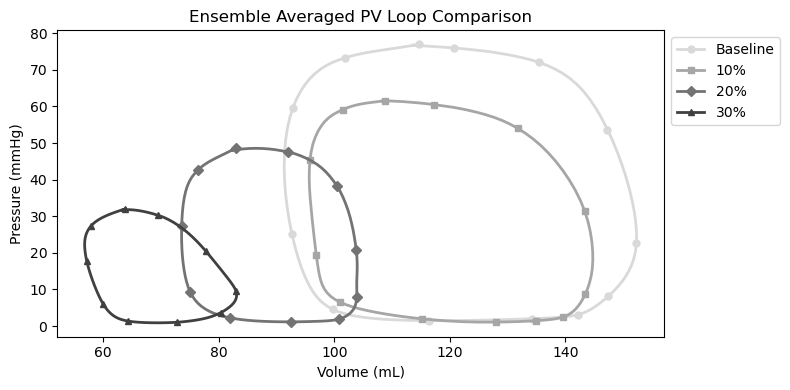

In [4]:
# -------------------------------
# Plot results with Savitzky-Golay smoothing
# -------------------------------

# Greyscale colors (light to dark)
line_colors = {
    "Baseline": "#D9D9D9",  # very light gray
    "10%": "#A6A6A6",       # light gray
    "20%": "#737373",       # medium gray
    "30%": "#404040"        # dark gray
}

# Marker styles for each group
marker_styles = {
    "Baseline": "o",   # circle
    "10%": "s",        # square
    "20%": "D",        # diamond
    "30%": "^"         # triangle
}

# Parameters for Savitzky-Golay filter
window_length = 19  # must be odd and <= length of your data
polyorder = 3       # polynomial order

plt.figure(figsize=(10, 4))

for key in universal_pressure.keys():
    group_name, time_point = key.split('_T')
    display_name = group_rename.get(group_name, group_name)

    color = line_colors.get(display_name, "gray")
    marker = marker_styles.get(display_name, "o")

    # Apply Savitzky-Golay filter
    smooth_pressure = savgol_filter(
        universal_pressure[key],
        window_length=window_length,
        polyorder=polyorder
    )

    smooth_volume = savgol_filter(
        universal_volume[key],
        window_length=window_length,
        polyorder=polyorder
    )

    plt.plot(
        smooth_volume,
        smooth_pressure,
        label=display_name,
        color=color,
        linewidth=2,
        marker=marker,
        markevery=10,      # place marker every 10 points to avoid clutter
        markersize=5
    )

plt.xlabel("Volume (mL)")
plt.ylabel("Pressure (mmHg)")
plt.title("Ensemble Averaged PV Loop Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

# Individual Time Points without shading

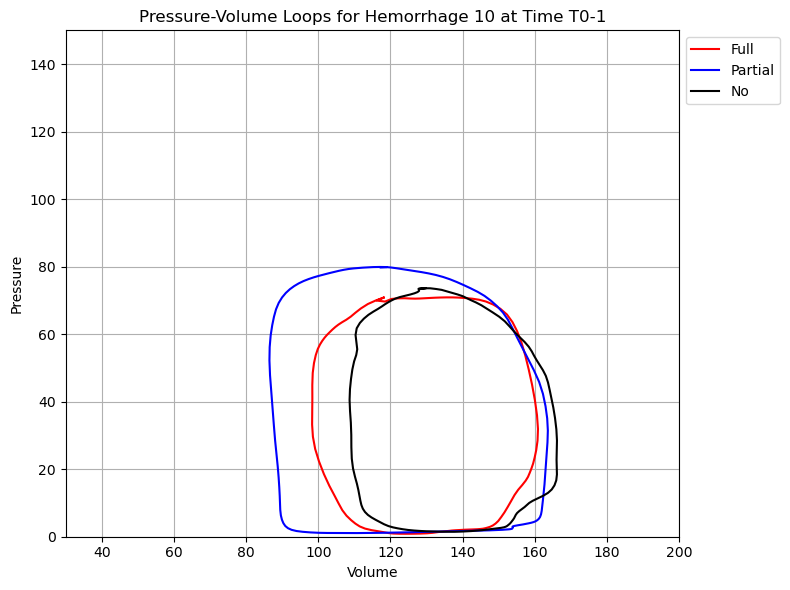

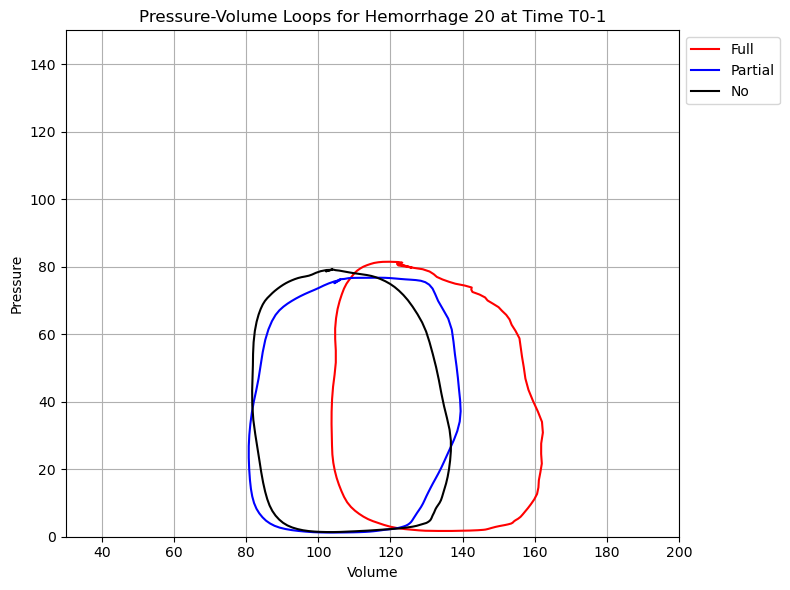

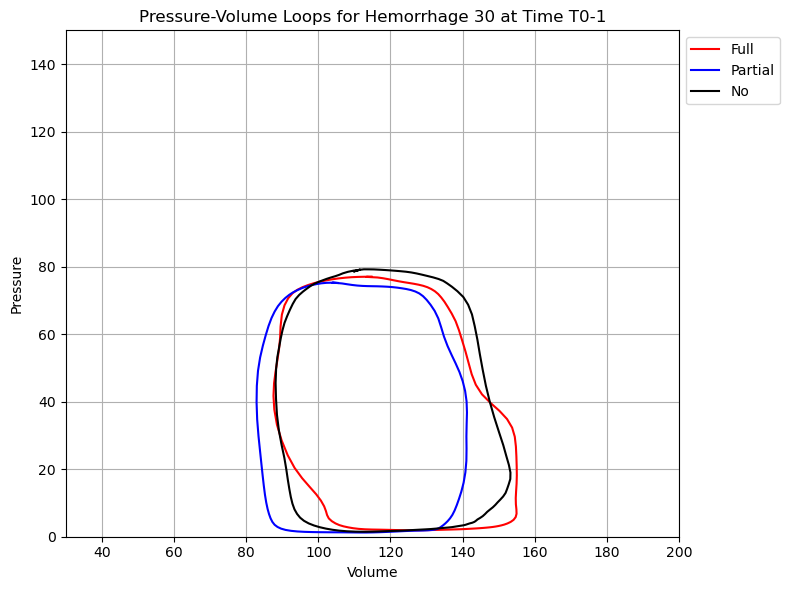

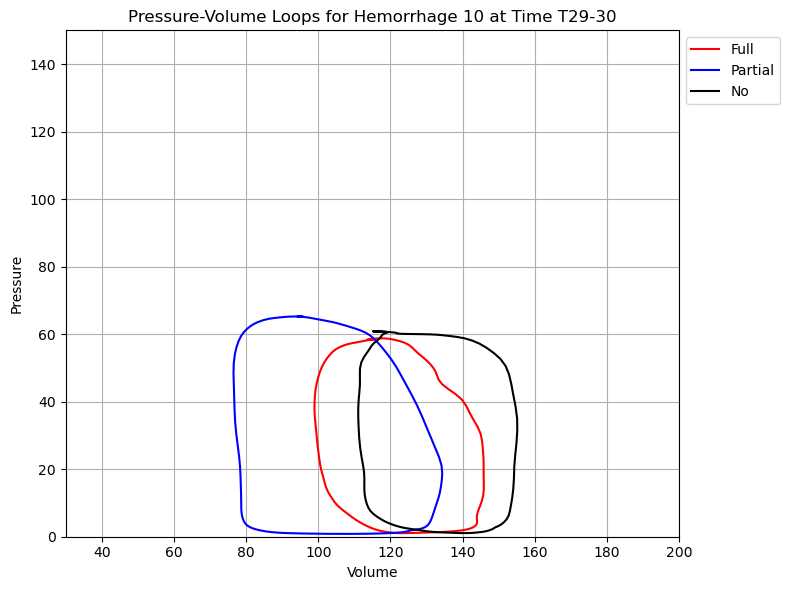

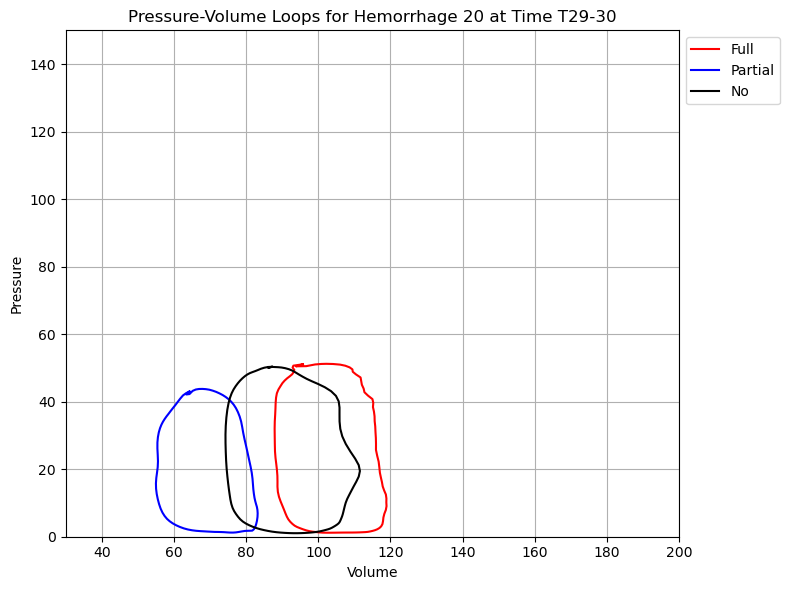

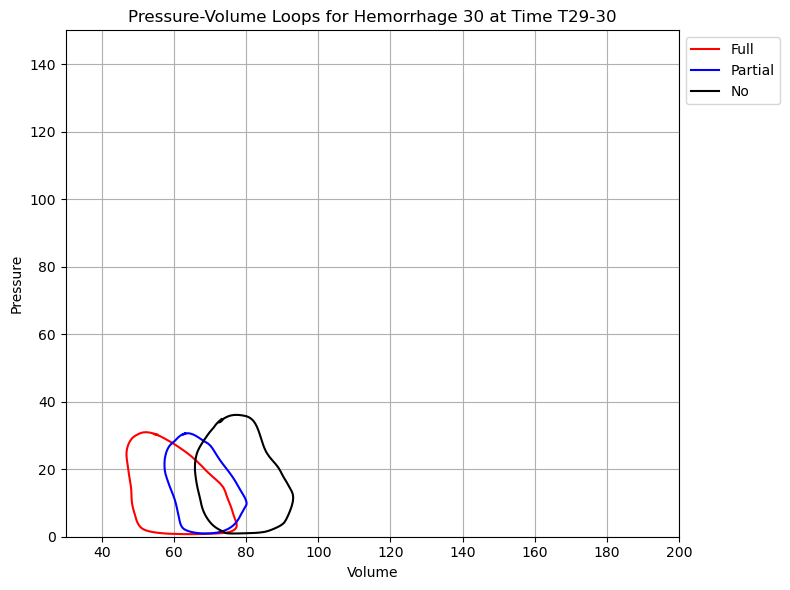

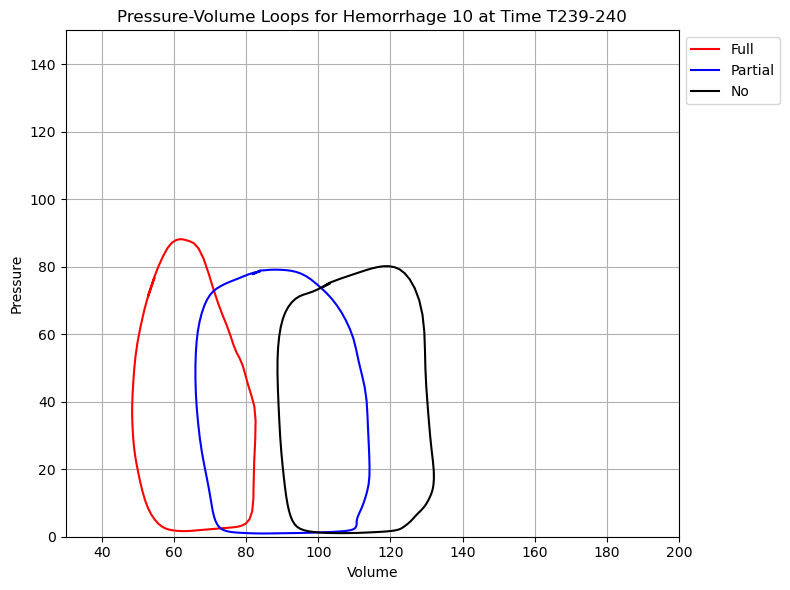

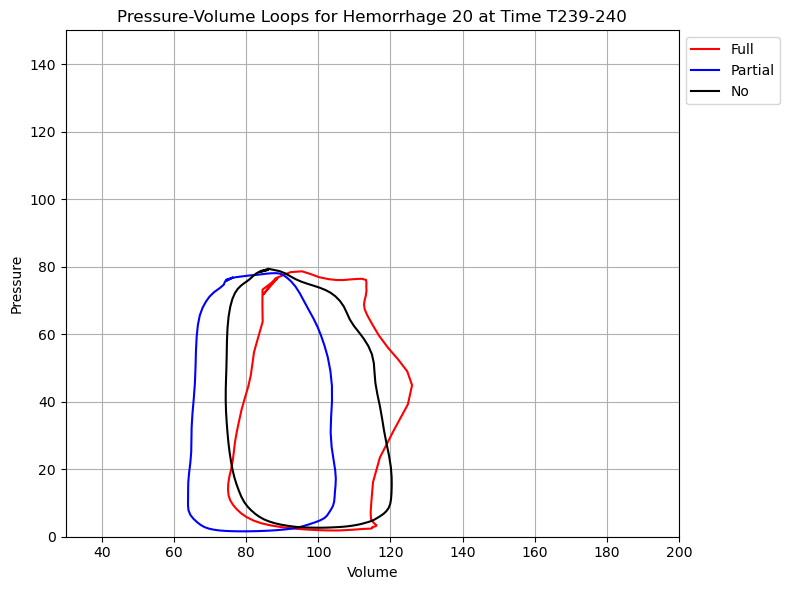

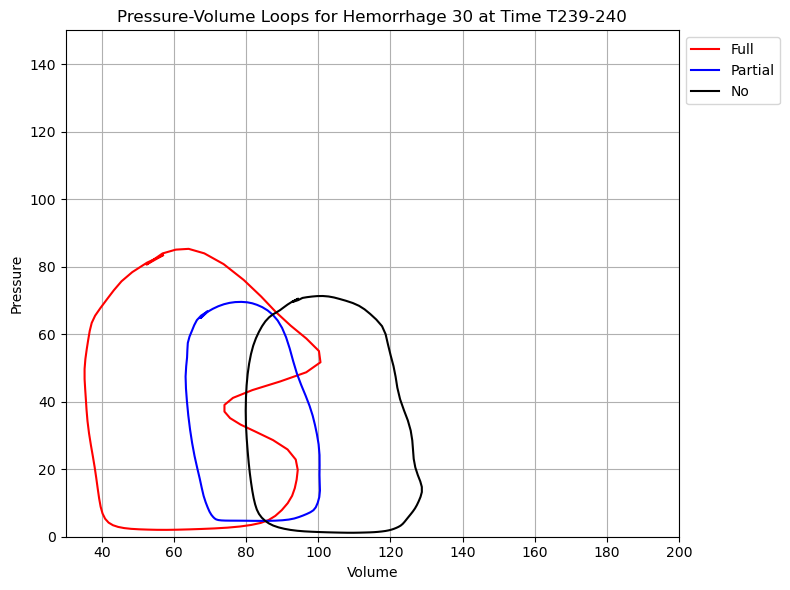

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load Excel data
df = pd.read_excel('PV_Ensemble_Data-Raw.xlsx')

# Define groups
groups = {
    "hemorrhage_10_full_occlusion": group_10.intersection(full_occlusion),
    "hemorrhage_10_partial_occlusion": group_10.intersection(partial_occlusion),
    "hemorrhage_10_no_occlusion": group_10.intersection(no_occlusion),
    "hemorrhage_20_full_occlusion": group_20.intersection(full_occlusion),
    "hemorrhage_20_partial_occlusion": group_20.intersection(partial_occlusion),
    "hemorrhage_20_no_occlusion": group_20.intersection(no_occlusion),
    "hemorrhage_30_full_occlusion": group_30.intersection(full_occlusion),
    "hemorrhage_30_partial_occlusion": group_30.intersection(partial_occlusion),
    "hemorrhage_30_no_occlusion": group_30.intersection(no_occlusion),
}

# Function to normalize array length
def resize_array(data, target_length):
    if len(data) == 0:
        return np.zeros((target_length, data.shape[1]))  # Return zeros if empty
    x_original = np.linspace(0, 1, len(data))
    x_target = np.linspace(0, 1, target_length)
    interpolator = interp1d(x_original, data, axis=0, kind='linear', fill_value='extrapolate')
    return interpolator(x_target)

# Process each group
universal_pressure = {}
universal_volume = {}

time_points = df['Time Point'].unique()

for time_point in time_points:
    df_time = df[df['Time Point'] == time_point]
    
    for group_name, parent_folders in groups.items():
        group_data = []
        for folder in parent_folders:
            subset = df_time[df_time['Parent Folder'] == folder].sort_values('Row Index')
            if not subset.empty:
                group_data.append(subset[['Pressure', 'Volume']].to_numpy())
        
        if not group_data:
            print(f"Skipping {group_name} at Time Point {time_point} (no data)")
            continue  # Skip empty groups
        
        # Determine average length
        avg_length = int(np.mean([len(data) for data in group_data]))
        
        # Resize each dataset
        resized_data = [resize_array(data, avg_length) for data in group_data]
        
        # Compute mean across resized datasets
        mean_pressure = np.mean([data[:, 0] for data in resized_data], axis=0)
        mean_volume = np.mean([data[:, 1] for data in resized_data], axis=0)
        
        key = f"{group_name}_T{time_point}"
        universal_pressure[key] = mean_pressure
        universal_volume[key] = mean_volume

# Define colors
group_colors = {
    "full": 'red',
    "partial": 'blue',
    "no": 'black',
}

# Mapping for simplified legend names
legend_labels = {
    "full_occlusion": "Full",
    "partial_occlusion": "Partial",
    "no_occlusion": "No",
}

# Generate plots for each hemorrhage group and each time point
for time_point in time_points:
    for group in ["hemorrhage_10", "hemorrhage_20", "hemorrhage_30"]:
        plt.figure(figsize=(8, 6))
        
        for key in universal_pressure.keys():
            if group in key and f"_T{time_point}" in key:  # Filter by group and time point
                # Extract occlusion type for legend
                for occlusion_type in legend_labels.keys():
                    if occlusion_type in key:
                        label = legend_labels[occlusion_type]
                        color = group_colors[occlusion_type.split('_')[0]]
                        break  # Found matching occlusion type, no need to continue loop

                plt.plot(
                    universal_volume[key],
                    universal_pressure[key],
                    label=label,
                    color=color
                )

        plt.title(f"Pressure-Volume Loops for {group.replace('_', ' ').title()} at Time {time_point}")
        plt.xlabel("Volume")
        plt.ylabel("Pressure")
        plt.xlim(30, 200)  # Set x-axis limit
        plt.ylim(0, 150)   # Set y-axis limit
        
        # Move legend outside the plot
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True)
        
        # Adjust layout to fit legend
        plt.tight_layout()
        
        # Show each plot
        plt.show()


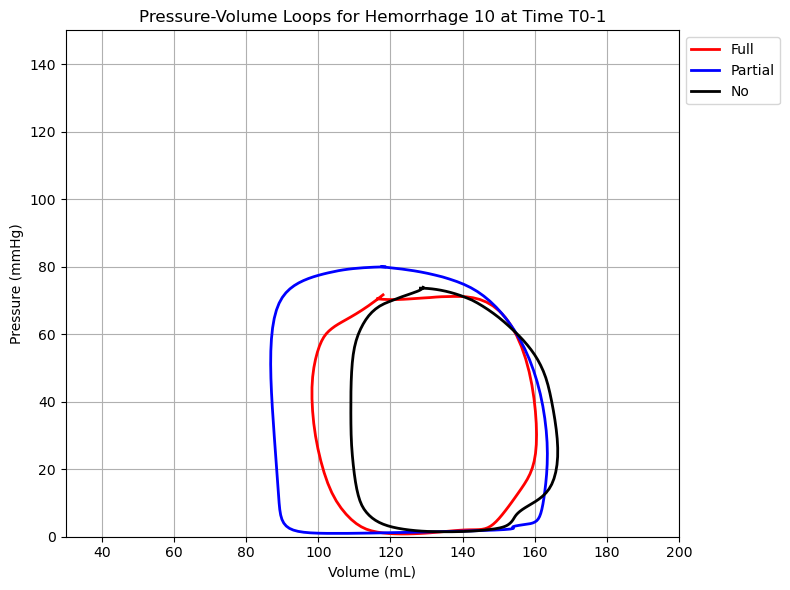

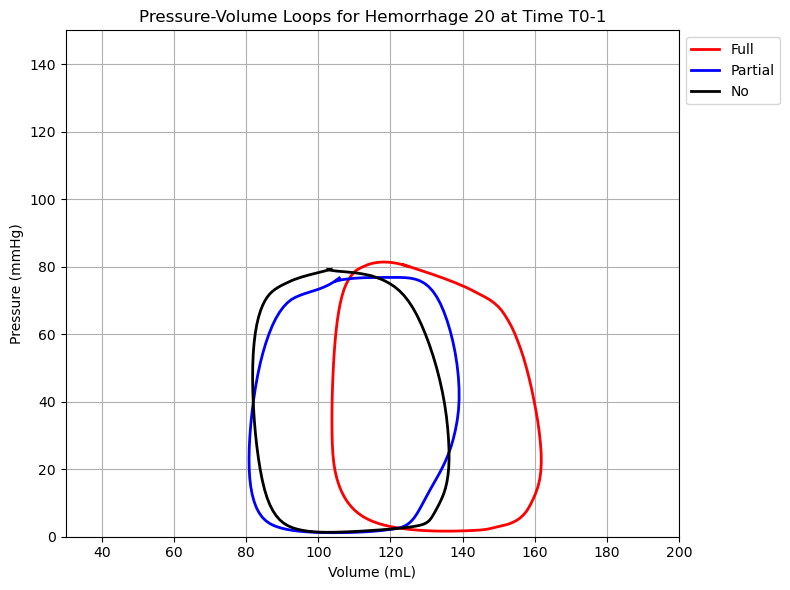

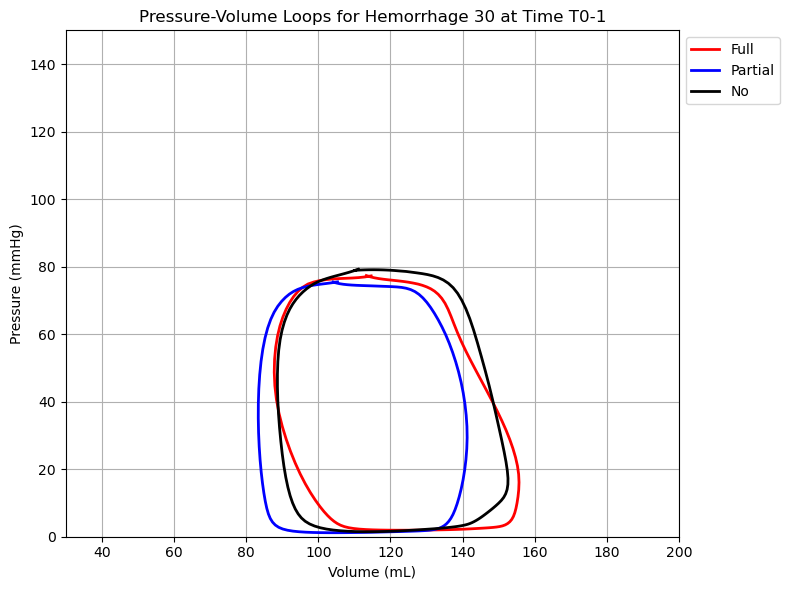

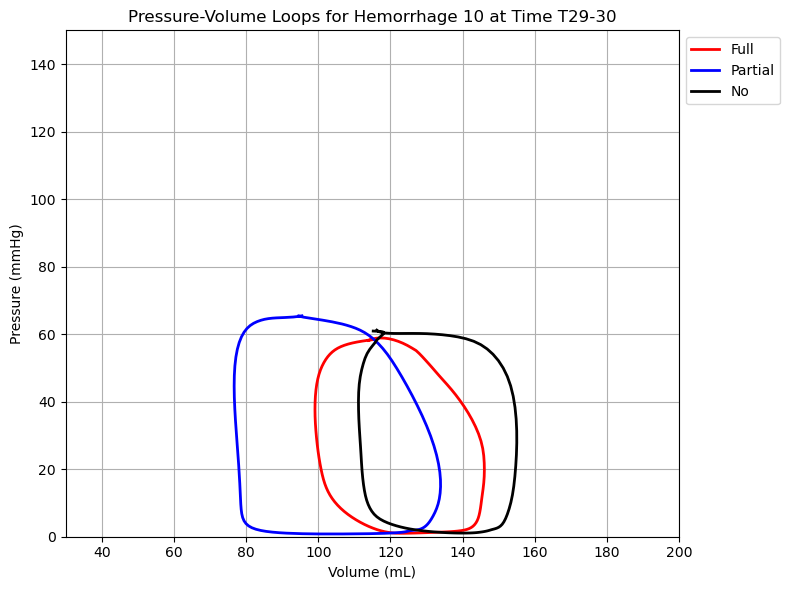

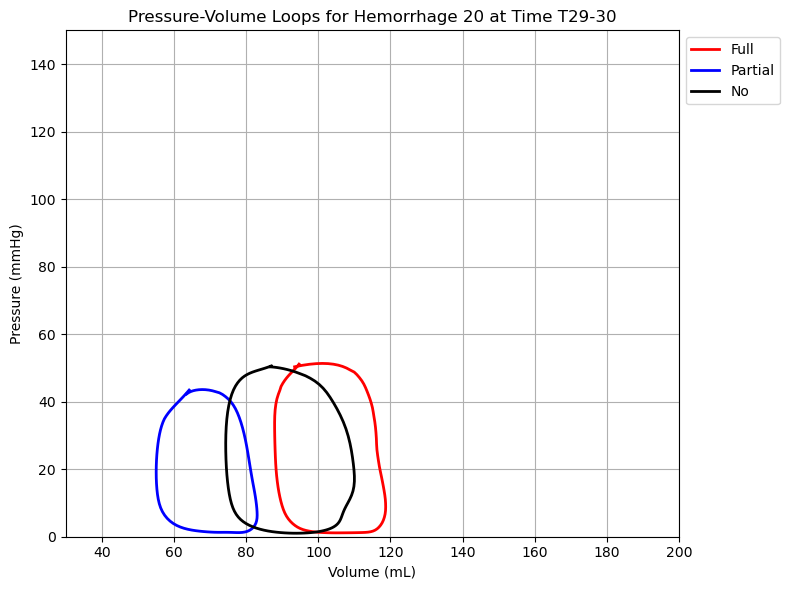

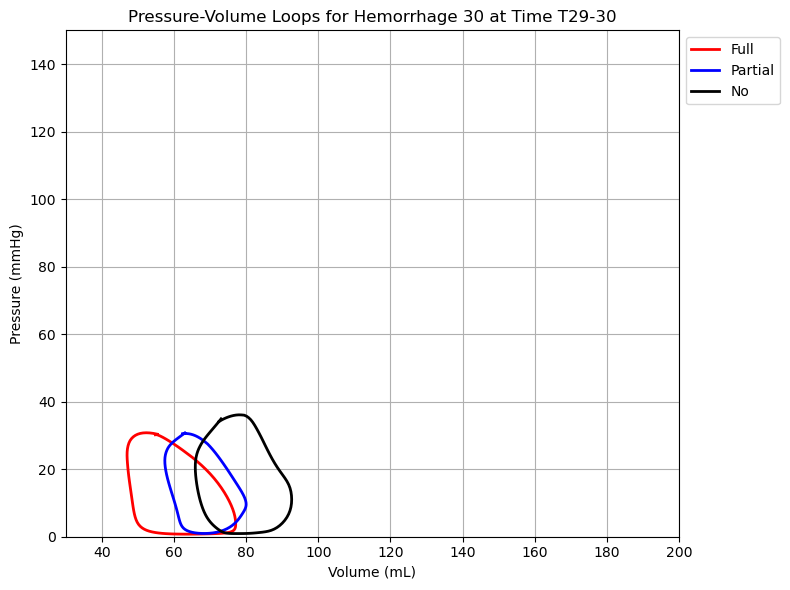

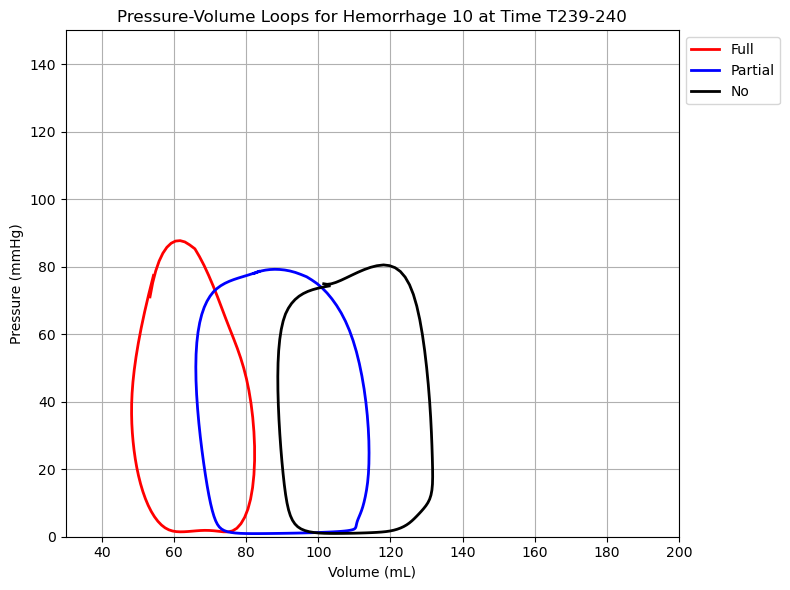

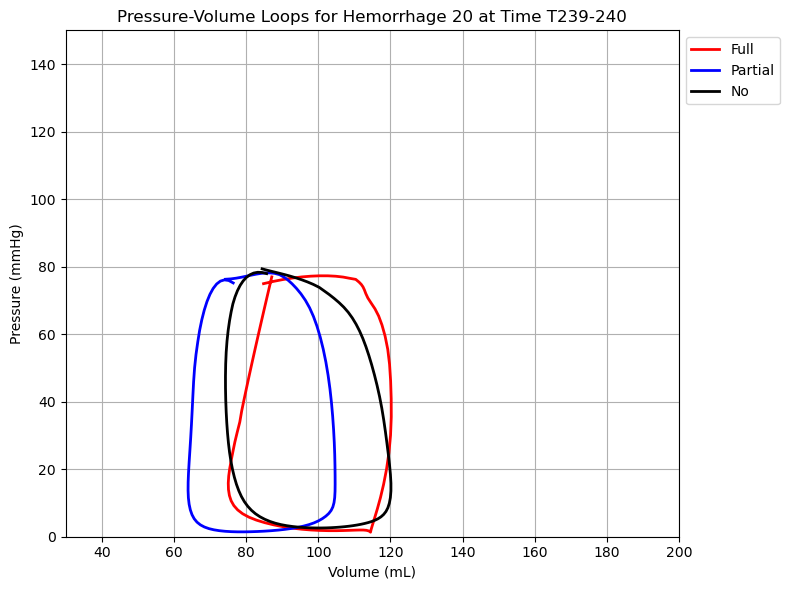

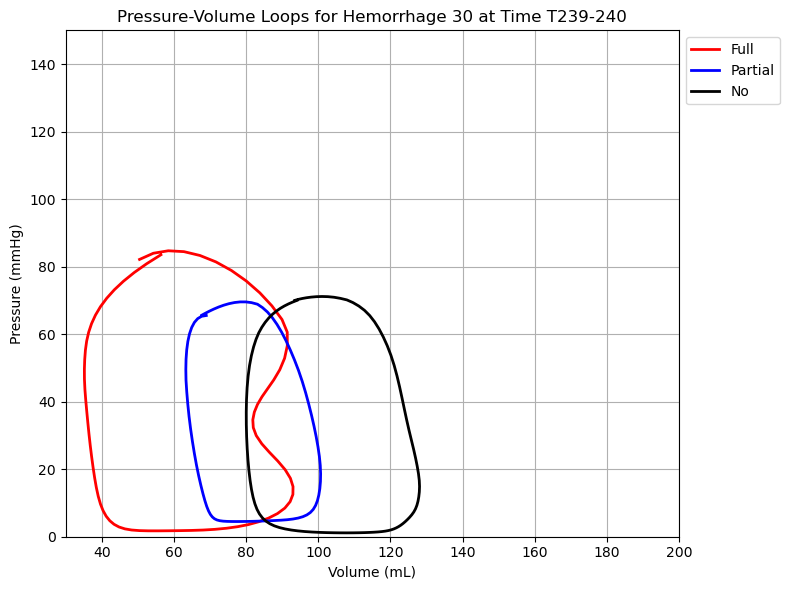

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# -------------------------------
# Load Excel data
# -------------------------------
df = pd.read_excel('PV_Ensemble_Data-Raw.xlsx')

# Define groups
groups = {
    "hemorrhage_10_full_occlusion": group_10.intersection(full_occlusion),
    "hemorrhage_10_partial_occlusion": group_10.intersection(partial_occlusion),
    "hemorrhage_10_no_occlusion": group_10.intersection(no_occlusion),
    "hemorrhage_20_full_occlusion": group_20.intersection(full_occlusion),
    "hemorrhage_20_partial_occlusion": group_20.intersection(partial_occlusion),
    "hemorrhage_20_no_occlusion": group_20.intersection(no_occlusion),
    "hemorrhage_30_full_occlusion": group_30.intersection(full_occlusion),
    "hemorrhage_30_partial_occlusion": group_30.intersection(partial_occlusion),
    "hemorrhage_30_no_occlusion": group_30.intersection(no_occlusion),
}

# -------------------------------
# Function to normalize array length
# -------------------------------
def resize_array(data, target_length):
    if len(data) == 0:
        return np.zeros((target_length, data.shape[1]))
    x_original = np.linspace(0, 1, len(data))
    x_target = np.linspace(0, 1, target_length)
    interpolator = interp1d(x_original, data, axis=0, kind='linear', fill_value='extrapolate')
    return interpolator(x_target)

# -------------------------------
# Process each group
# -------------------------------
universal_pressure = {}
universal_volume = {}

time_points = df['Time Point'].unique()

for time_point in time_points:
    df_time = df[df['Time Point'] == time_point]
    
    for group_name, parent_folders in groups.items():
        group_data = []
        for folder in parent_folders:
            subset = df_time[df_time['Parent Folder'] == folder].sort_values('Row Index')
            if not subset.empty:
                group_data.append(subset[['Pressure', 'Volume']].to_numpy())
        
        if not group_data:
            print(f"Skipping {group_name} at Time Point {time_point} (no data)")
            continue
        
        # Determine average length
        avg_length = int(np.mean([len(data) for data in group_data]))
        
        # Resize each dataset
        resized_data = [resize_array(data, avg_length) for data in group_data]
        
        # Compute mean across resized datasets
        mean_pressure = np.mean([data[:, 0] for data in resized_data], axis=0)
        mean_volume = np.mean([data[:, 1] for data in resized_data], axis=0)
        
        key = f"{group_name}_T{time_point}"
        universal_pressure[key] = mean_pressure
        universal_volume[key] = mean_volume

# -------------------------------
# Define colors (avoid red, blue, black)
# -------------------------------
group_colors = {
    "full": 'red',
    "partial": 'blue',
    "no": 'black',
}

# Legend mapping
legend_labels = {
    "full_occlusion": "Full",
    "partial_occlusion": "Partial",
    "no_occlusion": "No",
}

# Savitzky-Golay parameters
window_length = 21  # must be odd and <= data length
polyorder = 3

# -------------------------------
# Generate plots
# -------------------------------
for time_point in time_points:
    for group in ["hemorrhage_10", "hemorrhage_20", "hemorrhage_30"]:
        plt.figure(figsize=(8, 6))
        
        for key in universal_pressure.keys():
            if group in key and f"_T{time_point}" in key:
                # Determine occlusion type for legend and color
                for occlusion_type in legend_labels.keys():
                    if occlusion_type in key:
                        label = legend_labels[occlusion_type]
                        color = group_colors[occlusion_type.split('_')[0]]
                        break

                # Apply Savitzky-Golay smoothing
                smooth_pressure = savgol_filter(universal_pressure[key], window_length=window_length, polyorder=polyorder)
                smooth_volume = savgol_filter(universal_volume[key], window_length=window_length, polyorder=polyorder)

                plt.plot(
                    smooth_volume,
                    smooth_pressure,
                    label=label,
                    color=color,
                    linewidth=2
                )

        plt.title(f"Pressure-Volume Loops for {group.replace('_', ' ').title()} at Time {time_point}")
        plt.xlabel("Volume (mL)")
        plt.ylabel("Pressure (mmHg)")
        plt.xlim(30, 200)
        plt.ylim(0, 150)
        plt.grid(True)
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()


# Individual Time Points with Shading

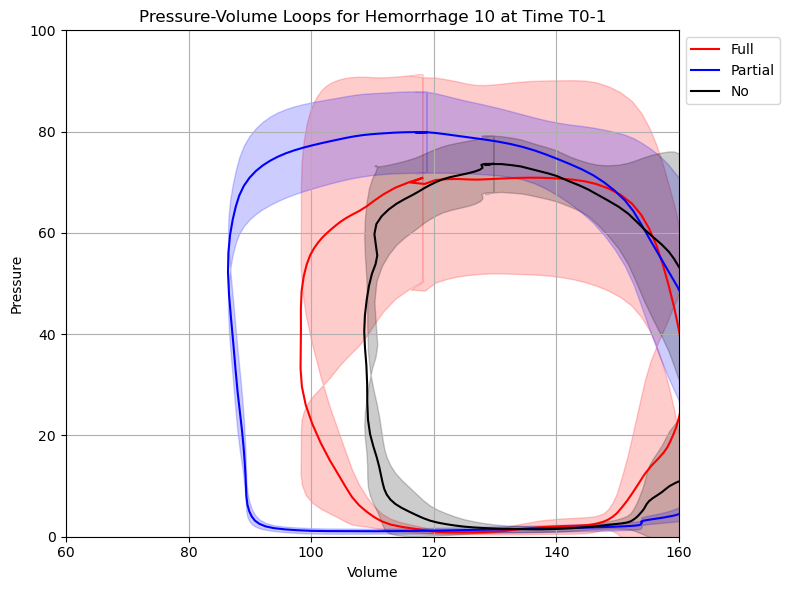

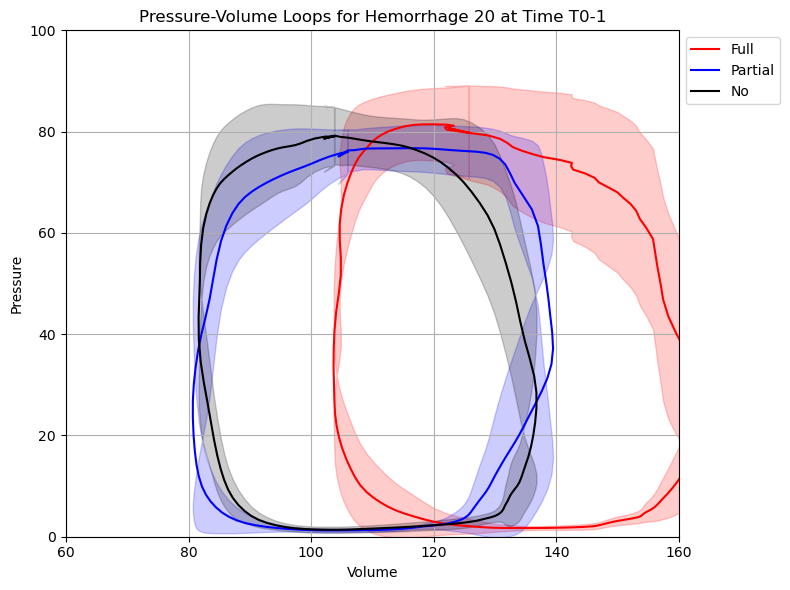

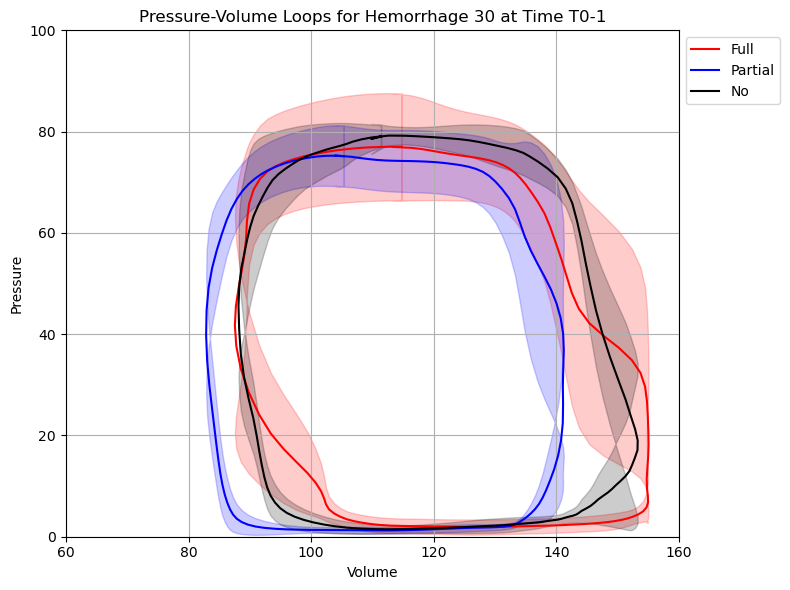

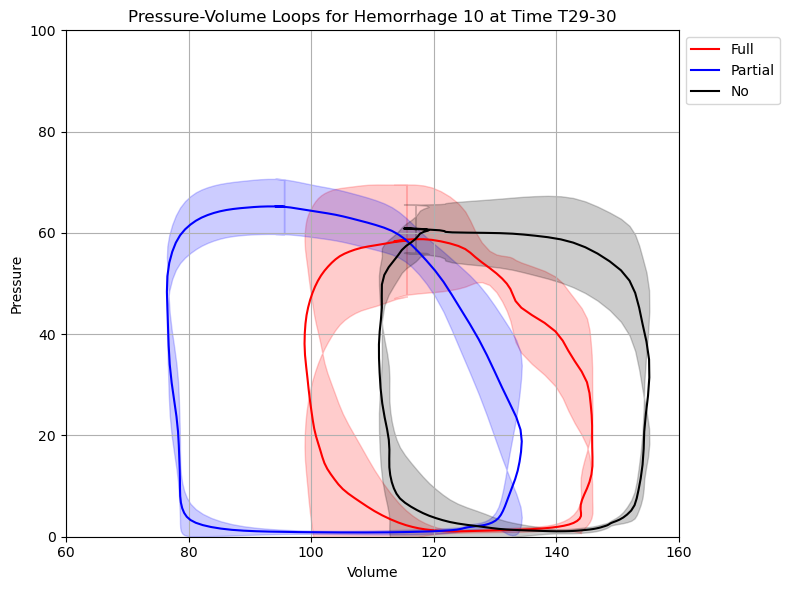

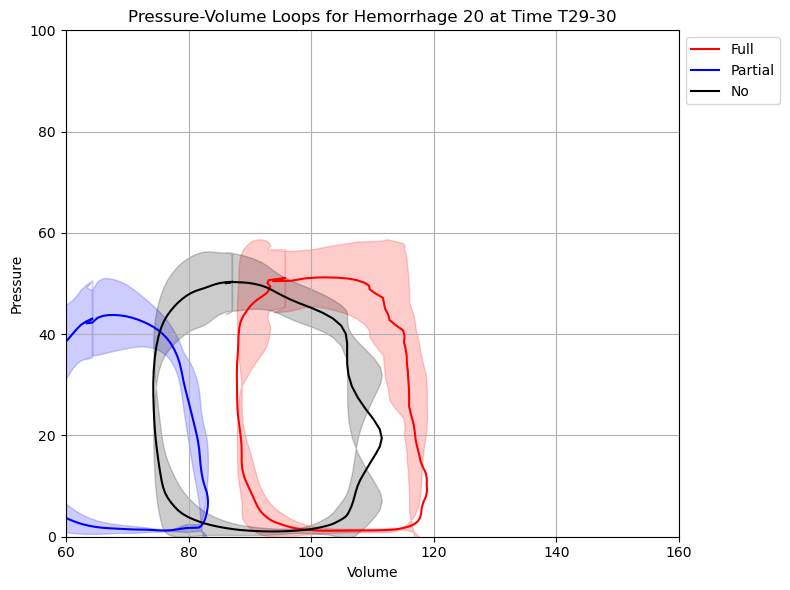

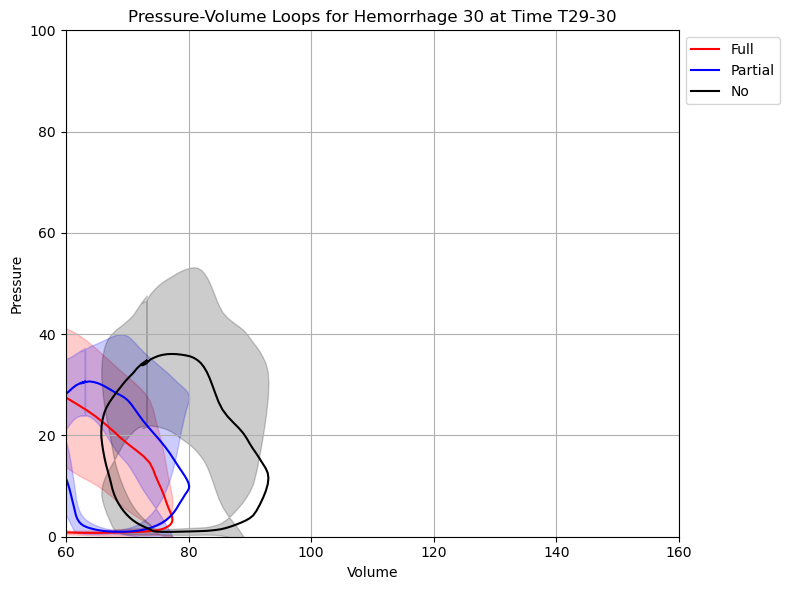

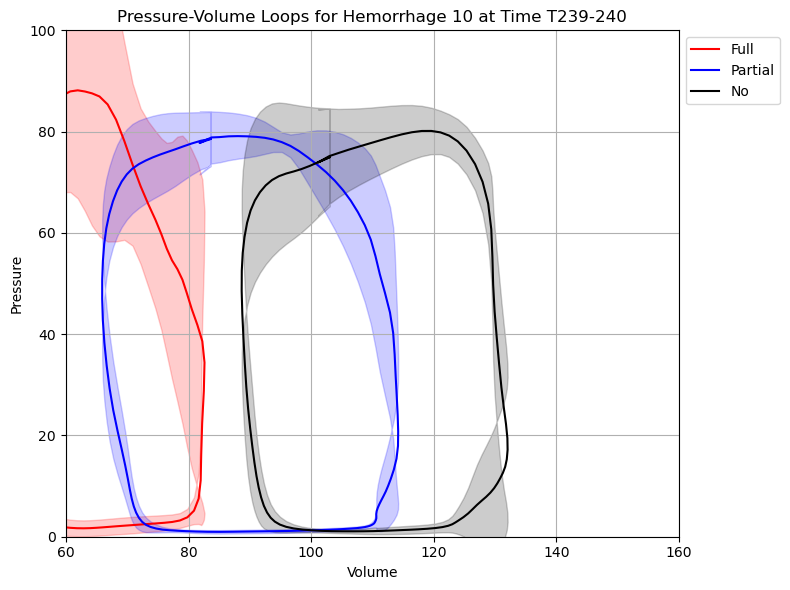

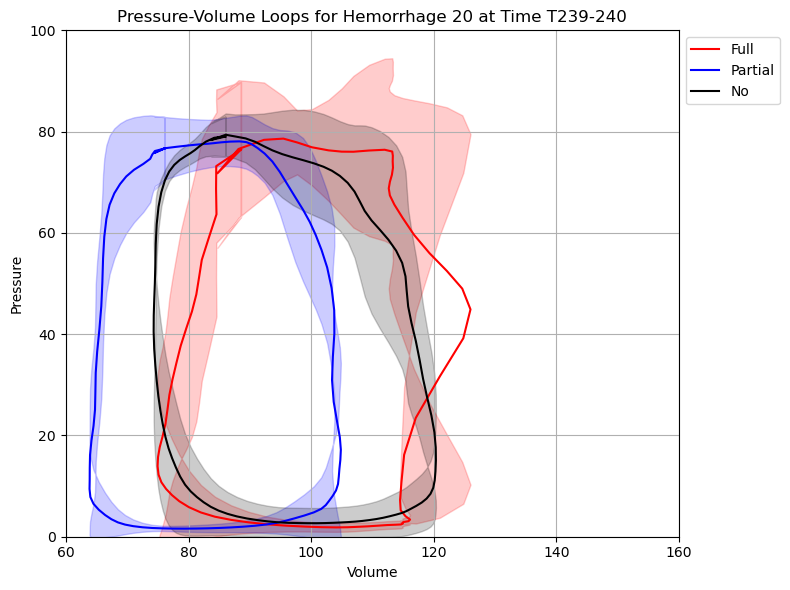

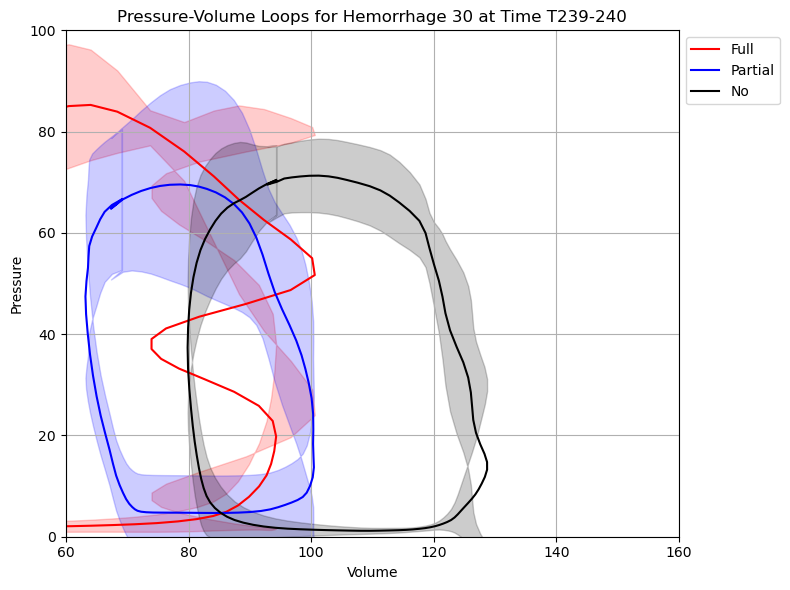

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load Excel data
df = pd.read_excel('PV_Ensemble_Data-Raw.xlsx')

# Define groups
groups = {
    "hemorrhage_10_full_occlusion": group_10.intersection(full_occlusion),
    "hemorrhage_10_partial_occlusion": group_10.intersection(partial_occlusion),
    "hemorrhage_10_no_occlusion": group_10.intersection(no_occlusion),
    "hemorrhage_20_full_occlusion": group_20.intersection(full_occlusion),
    "hemorrhage_20_partial_occlusion": group_20.intersection(partial_occlusion),
    "hemorrhage_20_no_occlusion": group_20.intersection(no_occlusion),
    "hemorrhage_30_full_occlusion": group_30.intersection(full_occlusion),
    "hemorrhage_30_partial_occlusion": group_30.intersection(partial_occlusion),
    "hemorrhage_30_no_occlusion": group_30.intersection(no_occlusion),
}

# Function to normalize array length
def resize_array(data, target_length):
    if len(data) == 0:
        return np.zeros((target_length, data.shape[1]))  # Return zeros if empty
    x_original = np.linspace(0, 1, len(data))
    x_target = np.linspace(0, 1, target_length)
    interpolator = interp1d(x_original, data, axis=0, kind='linear', fill_value='extrapolate')
    return interpolator(x_target)

# Process each group
universal_pressure = {}
universal_volume = {}
pressure_std = {}
volume_std = {}

time_points = df['Time Point'].unique()

for time_point in time_points:
    df_time = df[df['Time Point'] == time_point]
    
    for group_name, parent_folders in groups.items():
        group_data = []
        for folder in parent_folders:
            subset = df_time[df_time['Parent Folder'] == folder].sort_values('Row Index')
            if not subset.empty:
                group_data.append(subset[['Pressure', 'Volume']].to_numpy())
        
        if not group_data:
            print(f"Skipping {group_name} at Time Point {time_point} (no data)")
            continue  # Skip empty groups
        
        # Determine the length all datasets will be resized to
        avg_length = int(np.mean([len(data) for data in group_data]))
        
        # Resize each dataset
        resized_data = [resize_array(data, avg_length) for data in group_data]

        # Convert to NumPy array for proper indexing
        resized_data = np.array(resized_data)  # Shape: (num_samples, avg_length, 2)

        # Compute mean and row-wise standard deviation **properly aligned**
        mean_pressure = np.mean(resized_data[:, :, 0], axis=0)  # Mean pressure per time step
        std_pressure = np.std(resized_data[:, :, 0], axis=0)    # SD pressure per time step
        mean_volume = np.mean(resized_data[:, :, 1], axis=0)    # Mean volume per time step
        std_volume = np.std(resized_data[:, :, 1], axis=0)      # SD volume per time step
        
        key = f"{group_name}_T{time_point}"
        universal_pressure[key] = mean_pressure
        universal_volume[key] = mean_volume
        pressure_std[key] = std_pressure
        volume_std[key] = std_volume

# Define colors
group_colors = {
    "full": 'red',
    "partial": 'blue',
    "no": 'black',
}

# Mapping for simplified legend names
legend_labels = {
    "full_occlusion": "Full",
    "partial_occlusion": "Partial",
    "no_occlusion": "No",
}

# Generate plots for each hemorrhage group and each time point
for time_point in time_points:
    for group in ["hemorrhage_10", "hemorrhage_20", "hemorrhage_30"]:
        plt.figure(figsize=(8, 6))
        
        for key in universal_pressure.keys():
            if group in key and f"_T{time_point}" in key:  # Filter by group and time point
                # Extract occlusion type for legend
                for occlusion_type in legend_labels.keys():
                    if occlusion_type in key:
                        label = legend_labels[occlusion_type]
                        color = group_colors[occlusion_type.split('_')[0]]
                        break  # Found matching occlusion type, stop looping

                # Extract properly aligned data
                mean_vol = universal_volume[key]
                mean_pres = universal_pressure[key]
                std_pres = pressure_std[key]  # Row-by-row standard deviation

                # Plot the main pressure-volume loop
                plt.plot(mean_vol, mean_pres, label=label, color=color)

                # Fill between for **correctly aligned** standard deviation
                plt.fill_between(
                    mean_vol,  
                    mean_pres - std_pres,  # Lower bound
                    mean_pres + std_pres,  # Upper bound
                    color=color,  
                    alpha=0.2  # Transparency for shading
                )

        plt.title(f"Pressure-Volume Loops for {group.replace('_', ' ').title()} at Time {time_point}")
        plt.xlabel("Volume")
        plt.ylabel("Pressure")
        plt.xlim(60, 160)  # Set x-axis limit
        plt.ylim(0, 100)   # Set y-axis limit
        
        # Move legend outside the plot
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True)
        
        # Adjust layout to fit legend
        plt.tight_layout()
        
        # Show each plot
        plt.show()


In [12]:
print('Done')

Done
